# ANÁLISIS DE HIPERPARÁMETROS PARA EVALUAR VALORES ÓPTIMOS

Durante la fase de implementación se observó que en algunos casos el modelo no era capaz de encontrar contrafactuales válidos para una instancia determinada, por lo que en este cuaderno se presenta un análisis de las combinaciones de hiperparámetros más significativos para determinar los valores óptimos de manera genérica, debido a que el tiempo de cómputo en el hardware en que se desarrolló el modelo es del orden de ~1 hora (en el caso óptimo). Una especie de <span style="color:magenta">test de convergencia</span> con el objetivo de minimzar el costo computacional aumentando la probabildad de encontrar varios contrafactuales válidos.

Los parámetros determinados en este análisis no deben considerarse como perfectos, ya que el análisis contrafactual dependerá de la instancia y podría, con los valores acá presentados, no encontrar contrafactuales válidos o encontrar suficientes al poco tiempo de ejecución. Este proceso presenta valores sugeridos a partir de un análisis cuantitativo, que son presentados mediante tablas y gráficos.

Los códigos para el análisis se desarrollaron en el archivo `xai_utils/run_confetti_convergence.py`

In [1]:
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore', message='Unable to find acceptable character detection dependency')

from keras.models import load_model
import pickle

In [ ]:
from xai_utils import analyze_with_confetti
from xai_utils import (plot_best_counterfactual, plot_counterfactuals_by_diff,
                        plot_counterfactuals_by_ts, plot_counterfactual_channels,
                        plot_cf_summary)

In [2]:
def load_pickle(p_name):
    with open(p_name, 'rb') as file:
        # Load the data from the file
        data = pickle.load(file)
    return data

data_path = 'DATA\\'
#y_test = load_pickle(data_path+'ytest_new.pickle')
X_test = load_pickle(data_path+'xtest_new.pickle')
# y_train = load_pickle(data_path+'ytrain_new.pickle')
X_train = load_pickle(data_path+'xtrain_new.pickle')
# y_val = load_pickle(data_path+'yval_new.pickle')
# X_val = load_pickle(data_path+'xval_new.pickle')

In [3]:
model = load_model('MODELS\\transfer_learned_tsunami_classifier.keras') #Cargar modelo
for m in range(len(X_test)):
    instance = X_test[m:m+1] #Seleccionar la serie de tiempo a evaluar
    y = model.predict(instance, verbose=False) #Predecir para ver el resultado
    if (y>0.7) and (y<0.9): #Buscamos valores no muy extremos ni muy intermedio
        break
print(m, y)

39 [[0.7744924]]


In [4]:
from xai_utils import run_confetti_convergence

df_conv = run_confetti_convergence(
    model_path_wrapped='MODELS\\transfer_learned_tsunami_classifier_wrapped.keras',
    instance=instance,  # instancia con predicción 0.77
    X_train=X_train,
    use_cam_weights=False,
    save_path='CONVERGENCIA_CONFETTI\\'
)

Iniciando análisis de convergencia desde cero.


Total de combinaciones: 16
Pendientes: 16
Inicio: 17:19:32

------------------------------------------------------------
[✓ CF encontrado] pop=  50, gen=  50 | n_cfs= 41 | diff_mean=0.00022 | ts_mod=15 | t=2.0 min | fin: 17:21:34
[✓ CF encontrado] pop=  50, gen= 100 | n_cfs= 35 | diff_mean=0.00021 | ts_mod=14 | t=4.0 min | fin: 17:25:31
[✓ CF encontrado] pop=  50, gen= 200 | n_cfs= 49 | diff_mean=0.00020 | ts_mod=15 | t=8.0 min | fin: 17:33:29
[✓ CF encontrado] pop=  50, gen= 300 | n_cfs= 49 | diff_mean=0.00020 | ts_mod=15 | t=12.0 min | fin: 17:45:29
[✓ CF encontrado] pop= 100, gen=  50 | n_cfs= 42 | diff_mean=0.00023 | ts_mod=15 | t=2.3 min | fin: 17:47:45
[✓ CF encontrado] pop= 100, gen= 100 | n_cfs= 56 | diff_mean=0.00020 | ts_mod=16 | t=4.5 min | fin: 17:52:16
[✓ CF encontrado] pop= 100, gen= 200 | n_cfs= 55 | diff_mean=0.00019 | ts_mod=13 | t=9.0 min | fin: 18:01:15
[✓ CF encontrado] pop= 100, gen= 300 | n_cfs= 50 | diff_mean=0.000

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_confetti_convergence(df, fig_fmt='pdf', save_path=None):
    """
    Gráficos de convergencia para el análisis de CONFETTI.

    Genera 4 subplots en layout 2x2:
        - Heatmap de diff_mean por combinación de parámetros
        - Heatmap de timesteps_modificados por combinación
        - Heatmap de n_counterfactuals por combinación
        - Heatmap de tiempo de cómputo por combinación

    Args:
        df (pd.DataFrame): DataFrame retornado por run_confetti_convergence().
        fig_fmt (str):     Formato de figura: 'pdf' o 'png'. Default: 'pdf'.
        save_path (str):   Ruta base para guardar figura. Default: None.
    """
    pop_sizes = sorted(df['population_size'].unique())
    gen_sizes = sorted(df['generations'].unique())

    def make_matrix(col):
        """Construye matriz (pop x gen) para una columna dada."""
        m = np.full((len(pop_sizes), len(gen_sizes)), np.nan)
        for _, row in df.iterrows():
            i = pop_sizes.index(row['population_size'])
            j = gen_sizes.index(row['generations'])
            m[i, j] = row[col]
        return m

    metrics = [
        ('best_diff_mean',      'Diff media mejor CF',       'Greens_r'),
        ('best_ts_modificados', 'Timesteps modificados',     'Blues_r'),
        ('n_counterfactuals',   'N° contrafactuales',        'Purples'),
        ('tiempo_min',          'Tiempo de cómputo (min)',   'Oranges'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, (col, title, cmap) in zip(axes.flatten(), metrics):
        matrix = make_matrix(col)
        im = ax.imshow(matrix, cmap=cmap, aspect='auto')
        ax.set_xticks(range(len(gen_sizes)))
        ax.set_xticklabels(gen_sizes)
        ax.set_yticks(range(len(pop_sizes)))
        ax.set_yticklabels(pop_sizes)
        ax.set_xlabel('max_generations')
        ax.set_ylabel('population_size')
        ax.set_title(title)
        fig.colorbar(im, ax=ax)

        # Anotar valores en cada celda
        for i in range(len(pop_sizes)):
            for j in range(len(gen_sizes)):
                val = matrix[i, j]
                if not np.isnan(val):
                    txt = f'{val:.5f}' if col == 'best_diff_mean' else f'{val:.0f}'
                    ax.text(j, i, txt, ha='center', va='center',
                            fontsize=8, color='black')

    fig.suptitle('Análisis de convergencia CONFETTI\n'
                 '(valores menores de diff_mean y ts_modificados indican mejor calidad)',
                 fontsize=13)
    plt.tight_layout()

    if save_path:
        fig.savefig(f'{save_path}_convergencia_confetti.{fig_fmt}',
                    format=fig_fmt, dpi=300, bbox_inches='tight')
        print(f"Figura guardada: {save_path}_convergencia_confetti.{fig_fmt}")

    plt.show()

    # --- Gráfico 2: Curvas de convergencia por population_size ---
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

    for pop in pop_sizes:
        subset = df[df['population_size'] == pop].sort_values('generations')
        axes2[0].plot(subset['generations'], subset['best_diff_mean'],
                      marker='o', label=f'pop={pop}')
        axes2[1].plot(subset['generations'], subset['best_ts_modificados'],
                      marker='o', label=f'pop={pop}')

    axes2[0].set_xlabel('max_generations')
    axes2[0].set_ylabel('Diff media mejor CF')
    axes2[0].set_title('Calidad del CF vs generaciones')
    axes2[0].legend()
    axes2[0].grid(alpha=0.3)

    axes2[1].set_xlabel('max_generations')
    axes2[1].set_ylabel('Timesteps modificados')
    axes2[1].set_title('Sparsity del CF vs generaciones')
    axes2[1].legend()
    axes2[1].grid(alpha=0.3)

    fig2.suptitle('Convergencia CONFETTI — Calidad y Sparsity por population_size',
                  fontsize=13)
    plt.tight_layout()

    if save_path:
        fig2.savefig(f'{save_path}_convergencia_confetti_curvas.{fig_fmt}',
                     format=fig_fmt, dpi=300, bbox_inches='tight')
        print(f"Figura guardada: {save_path}_convergencia_confetti_curvas.{fig_fmt}")

    plt.show()


Figura guardada: CONVERGENCIA_CONFETTI\_convergencia_confetti.png


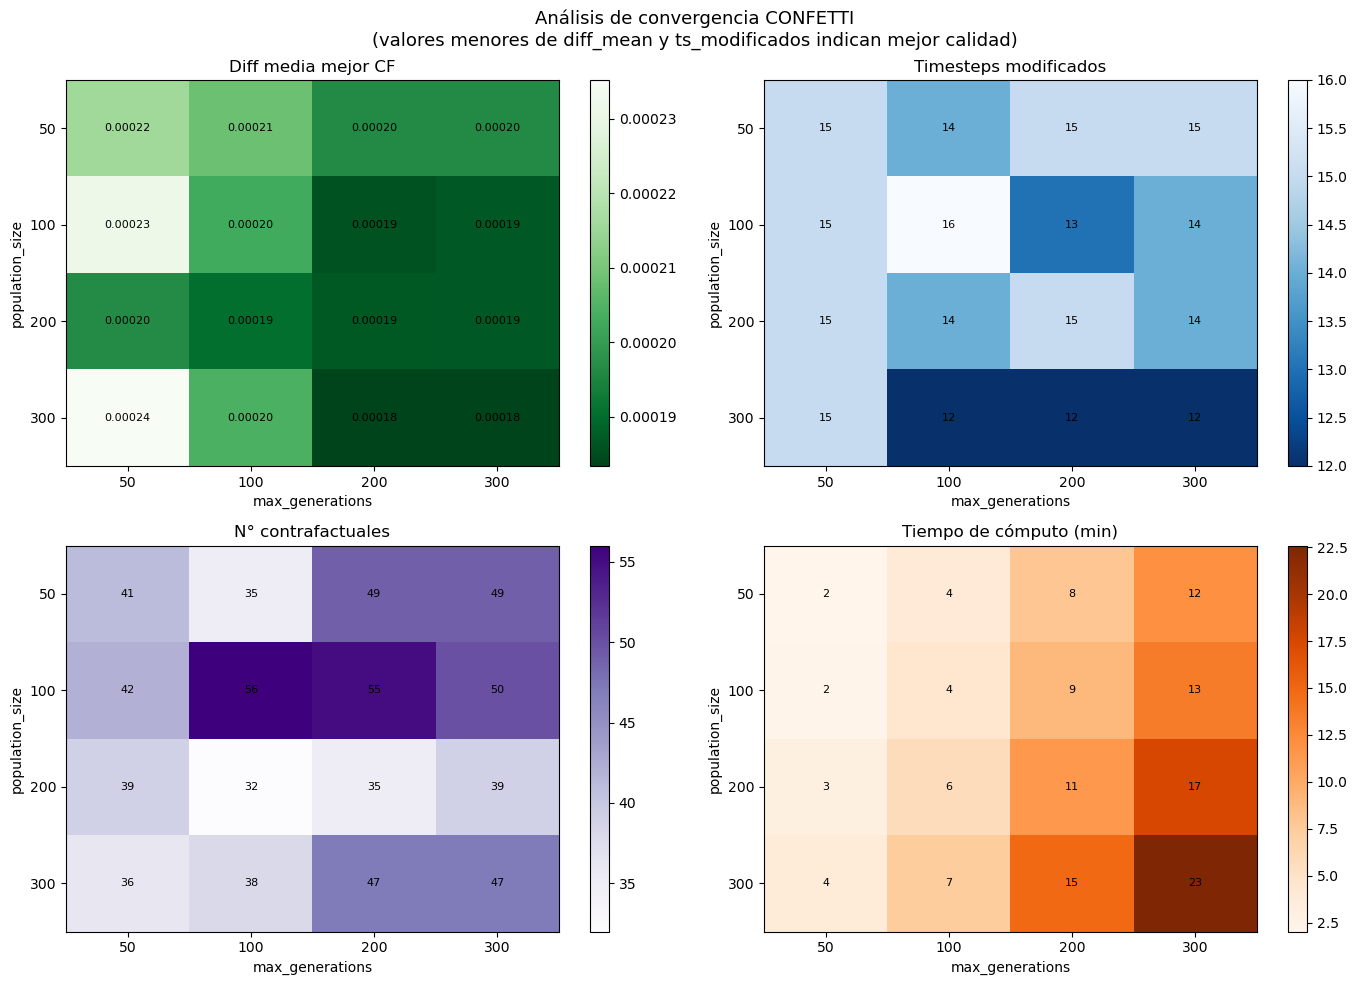

Figura guardada: CONVERGENCIA_CONFETTI\_convergencia_confetti_curvas.png


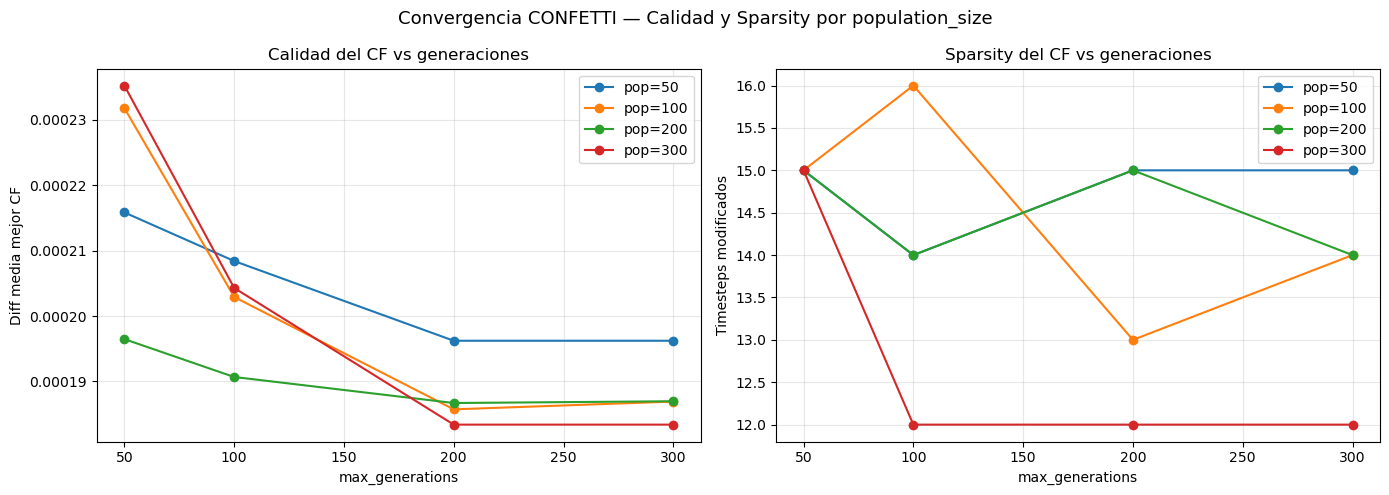

In [6]:
with open('CONVERGENCIA_CONFETTI\\convergence_results.pkl', 'rb') as f:
    df_conv = pickle.load(f)

plot_confetti_convergence(df_conv, fig_fmt='png',
                          save_path='CONVERGENCIA_CONFETTI\\')

| population_size | max_generations | diff_mean | ts_modificados | n_cfs | tiempo (min) |
|:-:|:-:|:-:|:-:|:-:|:-:|
| 50  | 50  | 0.00022 | 15 | 41 | 2.0  |
| 50  | 100 | 0.00021 | 14 | 35 | 4.0  |
| 50  | 200 | 0.00020 | 15 | 49 | 8.0  |
| 50  | 300 | 0.00020 | 15 | 49 | 12.0 |
| 100 | 50  | 0.00023 | 15 | 42 | 2.3  |
| 100 | 100 | 0.00020 | 16 | 56 | 4.5  |
| **100** | **200** | **0.00019** | **13** | **55** | **9.0** |
| 100 | 300 | 0.00019 | 14 | 50 | 13.5 |
| 200 | 50  | 0.00020 | 15 | 39 | 2.9  |
| 200 | 100 | 0.00019 | 14 | 32 | 5.7  |
| 200 | 200 | 0.00019 | 15 | 35 | 11.4 |
| 200 | 300 | 0.00019 | 14 | 39 | 17.5 |
| 300 | 50  | 0.00024 | 15 | 36 | 3.6  |
| 300 | 100 | 0.00020 | 12 | 38 | 7.3  |
| 300 | 200 | 0.00018 | 12 | 47 | 14.8 |
| 300 | 300 | 0.00018 | 12 | 47 | 22.6 |

Análisis:

Con el objetivo de determinar los parámetros óptimos del algoritmo genético de CONFETTI, se realizó un análisis de convergencia variando sistemáticamente population_size ∈ {50, 100, 200, 300} y max_generations ∈ {50, 100, 200, 300}, evaluando para cada combinación la calidad del mejor contrafactual encontrado (diff_mean), su sparsity (ts_modificados) y el tiempo de cómputo. Los resultados muestran que todas las combinaciones evaluadas encontraron contrafactuales válidos, con valores de diff_mean que oscilan entre 0.00018 y 0.00024, lo que indica una variación de calidad relativamente pequeña en el rango explorado. Sin embargo, se observa un punto de rendimiento decreciente claro: a partir de population_size=100 y max_generations=200, las mejoras en calidad son marginales (reducción de 0.00001 en diff_mean y 1 timestep en sparsity al aumentar al máximo explorado), mientras que el costo computacional aumenta significativamente. Por esta razón, se seleccionó la combinación population_size=100, max_generations=200 como configuración óptima, logrando un equilibrio entre calidad de los contrafactuales y eficiencia computacional, con un tiempo de ejecución de 9 minutos frente a los 22.6 minutos de la combinación de mayor presupuesto.

Vale hacer presente que para este análisis se usó una instancia que genera una predicción y=0.77, que corresponde a la instancia 39 del set de pruebas (X_test[39])